<a href="https://colab.research.google.com/github/csaibalakrishna/DL_BASED_RANSOMWARE/blob/main/DL_BASED_RANSOMWARE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries first
!pip install pandas numpy scikit-learn torch matplotlib seaborn openpyxl -q
print("Libraries installed ✅")

Libraries installed ✅


In [ ]:
# Upload your zip file
from google.colab import files
print("File picker will open — select your ransomware_project.zip file")
uploaded = files.upload()
print("Upload complete ✅")

File picker will open — select your ransomware_project.zip file


Saving ransomeware_project.zip to ransomeware_project (2).zip
Upload complete ✅


In [68]:
import os
import glob

base_path = "/content/ransomware_project/ransomeware_project"

ransomware_files = glob.glob(
    os.path.join(base_path, "**", "*ra*.csv"),
    recursive=True
)

benign_files = glob.glob(
    os.path.join(base_path, "**", "*be*.csv"),
    recursive=True
)

print("Ransomware CSV files found:", len(ransomware_files))
print("Benign CSV files found:", len(benign_files))

Ransomware CSV files found: 322
Benign CSV files found: 1727


In [1]:
import pandas as pd
import os
import glob
import numpy as np

base_path = "/content/ransomware_project/ransomeware_project"

ransomware_files = glob.glob(
    os.path.join(base_path, "**", "*ra*.csv"),
    recursive=True
)

benign_files = glob.glob(
    os.path.join(base_path, "**", "*be*.csv"),
    recursive=True
)

all_data = []

# Load ransomware files
for file in ransomware_files[:50]:

    try:
        df = pd.read_csv(file)

        df['Target'] = 1

        all_data.append(df)

    except:
        pass

# Load benign files
for file in benign_files[:120]:

    try:
        df = pd.read_csv(file)

        df['Target'] = 0

        all_data.append(df)

    except:
        pass

combined_df = pd.concat(all_data, ignore_index=True)

combined_df.columns = combined_df.columns.str.strip()

drop_columns = [
    'Flow ID',
    'Source IP',
    'Destination IP',
    'Timestamp',
    'Label'
]

combined_df = combined_df.drop(columns=drop_columns)

X = combined_df.drop(columns=['Target'])

y = combined_df['Target']

X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(0)

print(combined_df.shape)

print(y.value_counts())

(134136, 81)
Target
0    97922
1    36214
Name: count, dtype: int64


In [2]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(134136, 80)


In [3]:
sequence_length = 10

X_seq = []
y_seq = []

for i in range(len(X_scaled) - sequence_length):

    X_seq.append(X_scaled[i:i+sequence_length])

    y_seq.append(y.iloc[i+sequence_length])

X_seq = np.array(X_seq)

y_seq = np.array(y_seq)

print(X_seq.shape)

print(y_seq.shape)

(134126, 10, 80)
(134126,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(107300, 10, 80)
(26826, 10, 80)


In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

print("DataLoader Ready ✅")

DataLoader Ready ✅


In [23]:
import torch
import torch.nn as nn

class AttentionBiLSTM(nn.Module):

    def __init__(self, input_size, hidden_size):

        super(AttentionBiLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )

        self.attention = nn.Linear(hidden_size * 2, 1)

        self.fc = nn.Linear(hidden_size * 2, 1)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        lstm_out, _ = self.lstm(x)

        attention_weights = torch.softmax(
            self.attention(lstm_out),
            dim=1
        )

        context_vector = torch.sum(
            attention_weights * lstm_out,
            dim=1
        )

        output = self.fc(context_vector)

        output = self.sigmoid(output)

        return output

model = AttentionBiLSTM(
    input_size=80,
    hidden_size=64
)

criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

AttentionBiLSTM(
  (lstm): LSTM(80, 64, batch_first=True, bidirectional=True)
  (attention): Linear(in_features=128, out_features=1, bias=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [24]:
epochs = 25

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        outputs = model(X_batch).squeeze()

        y_batch = y_batch.float()

        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/25], Loss: 0.5840
Epoch [2/25], Loss: 0.5813
Epoch [3/25], Loss: 0.5801
Epoch [4/25], Loss: 0.5782
Epoch [5/25], Loss: 0.5770
Epoch [6/25], Loss: 0.5755
Epoch [7/25], Loss: 0.5729
Epoch [8/25], Loss: 0.5704
Epoch [9/25], Loss: 0.5671
Epoch [10/25], Loss: 0.5625
Epoch [11/25], Loss: 0.5580
Epoch [12/25], Loss: 0.5520
Epoch [13/25], Loss: 0.5453
Epoch [14/25], Loss: 0.5384
Epoch [15/25], Loss: 0.5302
Epoch [16/25], Loss: 0.5225
Epoch [17/25], Loss: 0.5145
Epoch [18/25], Loss: 0.5061
Epoch [19/25], Loss: 0.4974
Epoch [20/25], Loss: 0.4886
Epoch [21/25], Loss: 0.4803
Epoch [22/25], Loss: 0.4720
Epoch [23/25], Loss: 0.4646
Epoch [24/25], Loss: 0.4567
Epoch [25/25], Loss: 0.4486


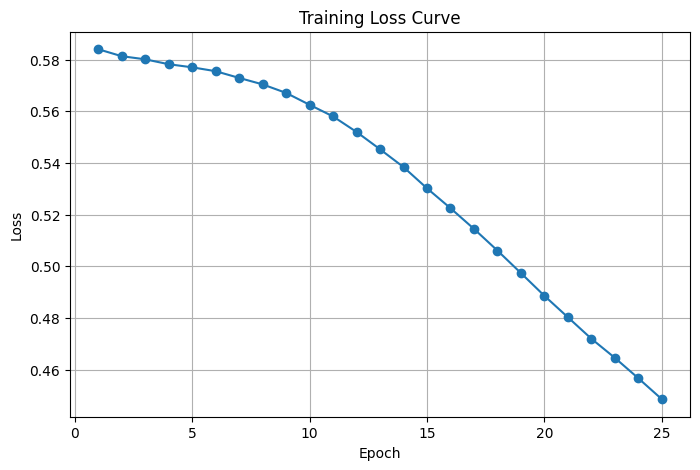

In [26]:
import matplotlib.pyplot as plt

loss_history = [
    0.5840, 0.5813, 0.5801, 0.5782, 0.5770,
    0.5755, 0.5729, 0.5704, 0.5671, 0.5625,
    0.5580, 0.5520, 0.5453, 0.5384, 0.5302,
    0.5225, 0.5145, 0.5061, 0.4974, 0.4886,
    0.4803, 0.4720, 0.4646, 0.4567, 0.4486
]

epochs = range(1, 26)

plt.figure(figsize=(8,5))

plt.plot(epochs, loss_history, marker='o')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Curve")

plt.grid(True)

plt.show()

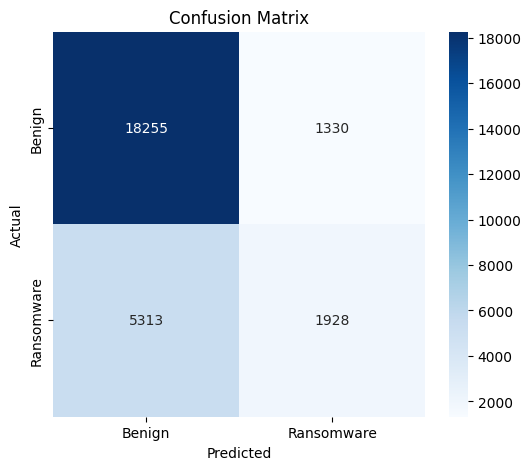

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign', 'Ransomware'],
    yticklabels=['Benign', 'Ransomware']
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

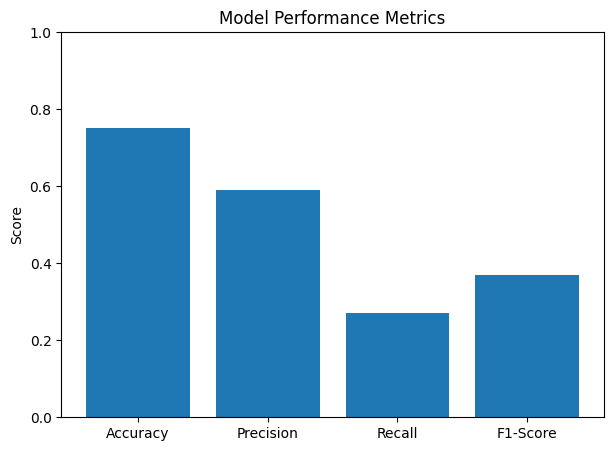

In [28]:
metrics = {
    'Accuracy': 0.752,
    'Precision': 0.59,
    'Recall': 0.27,
    'F1-Score': 0.37
}

plt.figure(figsize=(7,5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Model Performance Metrics")

plt.show()

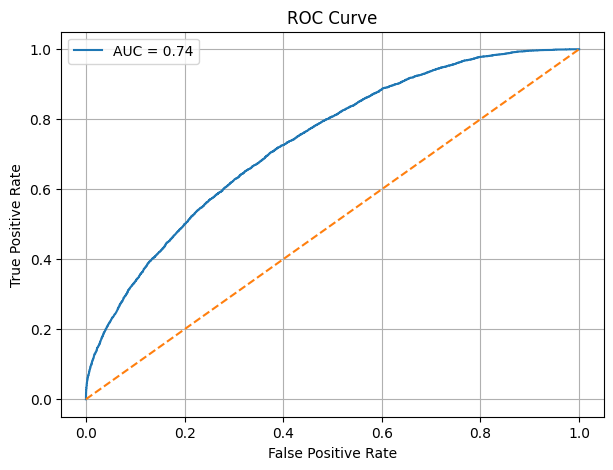

AUC Score: 0.7351470509269524


In [29]:
from sklearn.metrics import roc_curve, auc

model.eval()

probabilities = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch).squeeze()

        probabilities.extend(outputs.cpu().numpy())

fpr, tpr, thresholds = roc_curve(
    all_labels,
    probabilities
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

print("AUC Score:", roc_auc)

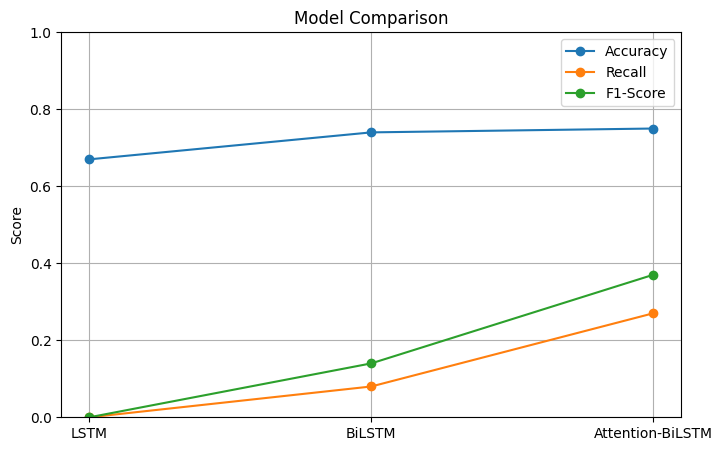

In [30]:
models = ['LSTM', 'BiLSTM', 'Attention-BiLSTM']

accuracy = [0.67, 0.74, 0.75]

recall = [0.00, 0.08, 0.27]

f1 = [0.00, 0.14, 0.37]

x = range(len(models))

plt.figure(figsize=(8,5))

plt.plot(x, accuracy, marker='o', label='Accuracy')

plt.plot(x, recall, marker='o', label='Recall')

plt.plot(x, f1, marker='o', label='F1-Score')

plt.xticks(x, models)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Model Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [42]:
combined_df.iloc[90000]

,90000
Source Port,46825.0
Destination Port,80.0
Protocol,6.0
Flow Duration,471723.0
Total Fwd Packets,3.0
...,...
Idle Mean,0.0
Idle Std,0.0
Idle Max,0.0
Idle Min,0.0


In [43]:
model.eval()

start_index = int(input("Enter starting row index: "))

sample_sequence = X_scaled[
    start_index:start_index+10
]

sample_tensor = torch.tensor(
    sample_sequence,
    dtype=torch.float32
).unsqueeze(0)

with torch.no_grad():

    prediction = model(sample_tensor)

    probability = prediction.item()

print("\n========== MODEL RESULT ==========")

print("Ransomware Probability:", probability)

if probability >= 0.5:

    print("Prediction: Ransomware")

else:

    print("Prediction: Benign")

actual_label = y.iloc[start_index + 10]

print("\n========== ACTUAL LABEL ==========")

if actual_label == 1:

    print("Actual: Ransomware")

else:

    print("Actual: Benign")

Enter starting row index: 90000

========== MODEL RESULT ==========
Ransomware Probability: 0.19525110721588135
Prediction: Benign

========== ACTUAL LABEL ==========
Actual: Benign
